In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model

2025-10-27 23:01:36.952051: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-27 23:01:36.952170: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-27 23:01:37.063286: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Getting the Arabic stopwords from NLTK
stop_words = set(stopwords.words('arabic'))

In [4]:
# Specify the path to your dataset directory
dataset_dir = "/kaggle/input/arabic-fake-news-dataset-afnd/AFND/Dataset"

In [5]:
# Read sources.json
sources_file_path = '/kaggle/input/arabic-fake-news-dataset-afnd/AFND/sources.json'
with open(sources_file_path, 'r', encoding='utf-8') as sources_file:
    sources_data = json.load(sources_file)
sources_df = pd.DataFrame(list(sources_data.items()), columns=['source', 'label'])

In [6]:
sources_df.head()

,source,label
0,source_1,credible
1,source_2,undecided
2,source_3,credible
3,source_4,credible
4,source_5,undecided


In [7]:
# Read scraped_articles.json for each source
articles_data = []

for source in sources_df['source']:
    scraped_articles_path = os.path.join(dataset_dir, source, 'scraped_articles.json')
    
    # Check if the file exists before attempting to read it
    if os.path.exists(scraped_articles_path):
        with open(scraped_articles_path, 'r', encoding='utf-8') as articles_file:
            source_articles_dict = json.load(articles_file)
            source_articles_list = source_articles_dict.get("articles", [])
            
            # Add a 'source' key to each article
            for article in source_articles_list:
                article['source'] = source
            
            articles_data.extend(source_articles_list)

# Convert articles_data to a DataFrame
articles_df = pd.DataFrame(articles_data)

In [8]:
# Merge the articles with their sources(labels)
merged_df = pd.merge(articles_df, sources_df, how='inner', left_on='source', right_on='source')

In [9]:
merged_df.head()

,title,text,published date,source,label
0,المنتخب الوطني المغربي لأقل من 20 سنة يخوض تجم...,يخوض المنتخب الوطني المغربي لكرة القدم لأقل من...,2021-05-23T00:00:00,source_1,credible
1,وزير النقل اعمارة:السرعة عامل مسبب لحوادث السي...,ترأس عبد القادر اعمارة، وزير التجهيز و النقل و...,2021-05-22T00:00:00,source_1,credible
2,"ميسي يؤكد أن الفوز بكأس اسبانيا كان ""نقطة تحول""",أكد النجم الارجنتيني ليونيل ميسي أن فوز فريقه ...,2021-05-22T00:00:00,source_1,credible
3,دبلوماسي مغربي سابق بإسبانيا لـ2M.ma: خطأ مدري...,أكّد الدبلوماسي المغربي السابق بإسبانيا، عبد ا...,2021-05-22T00:00:00,source_1,credible
4,شركتان، فرنسية وبريطانية تعلنان عن نتائج إيجاب...,أعلنت شركتا سانوفي الفرنسية العملاقة في تصنيع ...,2021-05-17T00:00:00,source_1,credible


In [10]:
merged_df.shape

(606912, 5)

Text(0, 0.5, '# of Articles')

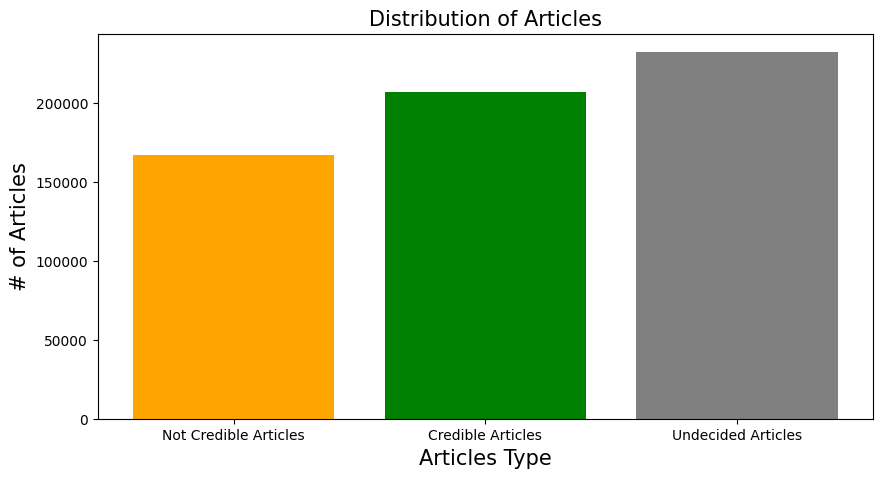

In [11]:
plt.figure(figsize=(10, 5))
plt.bar('Not Credible Articles', len(merged_df[merged_df['label'] == 'not credible']), color='orange')
plt.bar('Credible Articles', len(merged_df[merged_df['label'] == 'credible']), color='green')
plt.bar('Undecided Articles', len(merged_df[merged_df['label'] == 'undecided']), color='gray')
plt.title('Distribution of Articles', size=15)
plt.xlabel('Articles Type', size=15)
plt.ylabel('# of Articles', size=15)

In [12]:
# Data Preparation
X = merged_df['text']
y = merged_df['label']

In [13]:
# Remove Arabic stopwords
X = X.apply(lambda text: ' '.join([word for word in text.split() if word not in stop_words]))

In [14]:
# Use LabelEncoder to convert labels to numerical format
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [15]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [16]:
# Tokenization and Padding
max_vocab = 10000
tokenizer = Tokenizer(num_words=max_vocab)
tokenizer.fit_on_texts(X_train)

In [17]:
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

In [18]:
max_sequence_length = 128   # Set an appropriate value
X_train_padded = pad_sequences(X_train_sequences, maxlen=max_sequence_length, padding='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=max_sequence_length, padding='post')

In [19]:
# LSTM Model
model = Sequential()
model.add(Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=100, input_length=max_sequence_length))
model.add(SpatialDropout1D(0.2))  # Dropout layer for regularization
model.add(LSTM(units=64, return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(units=len(np.unique(y_encoded)), activation='softmax'))

In [20]:
# Compile the Model
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(1e-4),
              metrics=['accuracy'])

In [21]:
# Print the Model Summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 128, 100)          182679900 
                                                                 
 spatial_dropout1d (Spatial  (None, 128, 100)          0         
 Dropout1D)                                                      
                                                                 
 lstm (LSTM)                 (None, 128, 64)           42240     
                                                                 
 lstm_1 (LSTM)               (None, 64)                33024     
                                                                 
 dense (Dense)               (None, 3)                 195       
                                                                 
Total params: 182755359 (697.16 MB)
Trainable params: 182755359 (697.16 MB)
Non-trainable params: 0 (0.00 Byte)
__________

In [22]:
# Train the Model
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

model.fit(X_train_padded, y_train, epochs=10, validation_split=0.2, batch_size=64, shuffle=True, callbacks=[early_stop])

Epoch 1/10


I0000 00:00:1761606463.779368      69 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6070/6070 [==============================] - 293s 48ms/step - loss: 0.8895 - accuracy: 0.5654 - val_loss: 0.7996 - val_accuracy: 0.6268
Epoch 2/10
6070/6070 [==============================] - 208s 34ms/step - loss: 0.7581 - accuracy: 0.6567 - val_loss: 0.7261 - val_accuracy: 0.6686
Epoch 3/10
6070/6070 [==============================] - 201s 33ms/step - loss: 0.6930 - accuracy: 0.6866 - val_loss: 0.6950 - val_accuracy: 0.6788
Epoch 4/10
6070/6070 [==============================] - 201s 33ms/step - loss: 0.6587 - accuracy: 0.7028 - val_loss: 0.6815 - val_accuracy: 0.6864
Epoch 5/10
6070/6070 [==============================] - 199s 33ms/step - loss: 0.6340 - accuracy: 0.7148 - val_loss: 0.6622 - val_accuracy: 0.6963
Epoch 6/10
6070/6070 [==============================] - 199s 33ms/step - loss: 0.6142 - accuracy: 0.7249 - val_loss: 0.6618 - val_accuracy: 0.6998
Epoch 7/10
6070/6070 [==============================] - 198s 33ms/step - loss: 0.5982 - accuracy: 0.7331 - val_loss: 0.6603 - val

In [23]:
# Evaluate the Model
y_pred_probs = model.predict(X_test_padded)
y_pred = np.argmax(y_pred_probs, axis=1)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

3794/3794 [==============================] - 21s 5ms/step
Test Accuracy: 0.7005


In [24]:
# Evaluate other metrics
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.69      0.73     41308
           1       0.65      0.59      0.62     33392
           2       0.68      0.79      0.73     46683

    accuracy                           0.70    121383
   macro avg       0.70      0.69      0.69    121383
weighted avg       0.70      0.70      0.70    121383



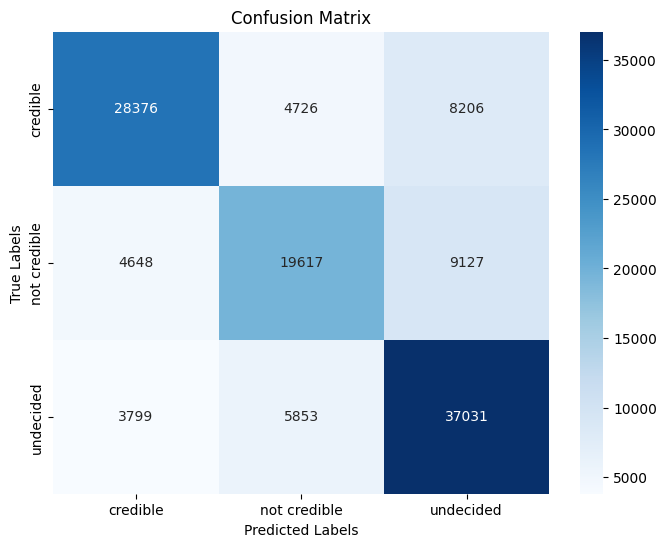

In [25]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [26]:
def predict_manual_text(text, tokenizer, model, max_sequence_length, label_encoder):
    seq = tokenizer.texts_to_sequences([text])
    seq_padded = pad_sequences(seq, maxlen=max_sequence_length, padding='post')
    probs = model.predict(seq_padded)
    pred_class_index = np.argmax(probs, axis=1)[0]
    pred_label = label_encoder.inverse_transform([pred_class_index])[0]
    
    # عرض النتيجة والاحتمال
    pred_prob = probs[0][pred_class_index]
    print("📰 النص:")
    print(text)
    print("📊 التصنيف المتوقع:", pred_label)
    print(f"🎯 نسبة الثقة: {pred_prob*100:.2f}%")
    return pred_label, pred_prob

# مثال للاختبار
manual_text = ""
predict_manual_text(manual_text, tokenizer, model, max_sequence_length, label_encoder)


1/1 [==============================] - 0s 37ms/step
📰 النص:

📊 التصنيف المتوقع: undecided
🎯 نسبة الثقة: 41.84%


('undecided', 0.4183822)

In [27]:
model.save('/kaggle/working/arabic_fake_news_lstm.keras')

In [28]:
model = load_model('/kaggle/working/arabic_fake_news_lstm.keras')

In [29]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_from_csv(csv_path, tokenizer, model, max_sequence_length, label_encoder, text_column='Article_Text'):
    """
    يقرأ الأخبار من ملف CSV، ويتنبأ إذا كانت Fake أو Real،
    ويعرض النتيجة لكل صف.
    """
    # قراءة الملف
    df = pd.read_csv(csv_path, encoding='utf-8')
    
    # التأكد من وجود العمود
    if text_column not in df.columns:
        raise ValueError(f"❌ العمود '{text_column}' غير موجود في الملف!")
    
    # حذف الصفوف الفارغة
    df = df.dropna(subset=[text_column])
    
    # تحويل النصوص إلى تسلسلات
    sequences = tokenizer.texts_to_sequences(df[text_column].tolist())
    seq_padded = pad_sequences(sequences, maxlen=max_sequence_length, padding='post')
    
    # التنبؤ
    probs = model.predict(seq_padded, verbose=0)
    pred_classes = np.argmax(probs, axis=1)
    pred_labels = label_encoder.inverse_transform(pred_classes)
    confidences = [probs[i, pred_classes[i]] for i in range(len(pred_classes))]
    
    # دمج النتائج مع النصوص الأصلية
    results_df = pd.DataFrame({
        'Article_text': df[text_column],
        'Predicted_Label': pred_labels,
        'Confidence': np.round(np.array(confidences) * 100, 2)
    })
    
    # طباعة أول 10 نتائج فقط لتوضيح الشكل
    print(results_df.head(10))
    
    return results_df

# مثال للتشغيل على ملفك
csv_path = '/kaggle/input/scraped/elshrouk.csv'
results = predict_from_csv(csv_path, tokenizer, model, max_sequence_length, label_encoder)


                                        Article_text Predicted_Label  \
0  وجه الرئيس الأمريكي دونالد ترامب، رسالة جديدة ...        credible   
1  أكد رئيس هيئة شؤون الأسرى والمحررين، رائد أبو ...        credible   
2  قال مكتب رئيس الوزراء الإسرائيلي، مساء السبت، ...        credible   
3  جدد الرئيس الأمريكي دونالد ترامب تأكيده أنه لن...        credible   
4  أشاد الإعلامي عمرو أديب، بالدور المصري المبادر...        credible   
5  قال آلان شيرر، نجم منتخب إنجلترا ونيوكاسل السا...        credible   
6  ظهر الفنان محمد سلام، اليوم السبت، في احتفالية...        credible   
7  بينما كانت المسنة رسمية بدر شكارنة (70 عاما) ت...        credible   
8  وقع حادث تصادم بين عدد من السيارات الملاكى وسي...        credible   
9  أكد مركز الأزهر العالمي للفتوى الإلكترونية أن ...        credible   

   Confidence  
0   78.980003  
1   87.739998  
2   82.410004  
3   83.910004  
4   68.300003  
5   89.220001  
6   83.309998  
7   68.720001  
8   68.180000  
9   79.540001  


In [30]:
# مثال للاختبار
manual_text ="أعلن باحثون في جامعة الإسكندرية عن اكتشاف دواء طبيعي يمكنه علاج جميع أنواع السرطان خلال أسبوع واحد فقط، دون أي آثار جانبية، وسيتم طرحه في الصيدليات الشهر القادم. "
predict_manual_text(manual_text, tokenizer, model, max_sequence_length, label_encoder)


1/1 [==============================] - 0s 20ms/step
📰 النص:
أعلن باحثون في جامعة الإسكندرية عن اكتشاف دواء طبيعي يمكنه علاج جميع أنواع السرطان خلال أسبوع واحد فقط، دون أي آثار جانبية، وسيتم طرحه في الصيدليات الشهر القادم. 
📊 التصنيف المتوقع: undecided
🎯 نسبة الثقة: 53.46%


('undecided', 0.5345746)